# Desafio Final — Análise de Dados de Energia com API Pública

**Curso:** Ciência da Computação  
**Disciplina:** Soluções em Energias Renováveis e Sustentáveis

## Situação-problema

Uma equipe de planejamento energético precisa analisar o comportamento da carga elétrica de uma região atendida pelo Sistema Interligado Nacional (SIN).

Os dados serão obtidos diretamente de uma API pública do **Operador Nacional do Sistema Elétrico (ONS)**. A conexão com a API e a preparação inicial do JSON já estão fornecidas. A partir daí, sua equipe deverá construir o DataFrame, organizar os dados, criar recortes, calcular indicadores, produzir gráficos e elaborar um relatório técnico.

> Todos os códigos, resultados, gráficos e respostas devem permanecer neste mesmo Notebook.

## 1. Fonte dos dados

API pública de **Carga Verificada do ONS**:

- Portal: https://dados.ons.org.br/
- Conjunto de dados: https://dados.ons.org.br/dataset/carga-energia-verificada

Neste notebook será utilizada inicialmente a área **SP — São Paulo**, no período de **01/08/2025 a 07/08/2025**.

## 2. Bibliotecas

In [4]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Consulta à API

Esta célula está pronta. Não é necessário conhecer `requests` para realizar o desafio.

In [5]:
url = "https://apicarga.ons.org.br/prd/cargaverificada"

parametros = {
    "dat_inicio": "2025-08-01",
    "dat_fim": "2025-08-07",
    "cod_areacarga": "SP"
}

response = requests.get(url, params=parametros, timeout=30)

print("Status:", response.status_code)
print("URL:", response.url)

response.raise_for_status()
dados_json = response.json()

Status: 200
URL: https://apicarga.ons.org.br/prd/cargaverificada?dat_inicio=2025-08-01&dat_fim=2025-08-07&cod_areacarga=SP


## 4. Preparação inicial do JSON

A célula abaixo localiza a lista principal de registros retornada pela API e a armazena em `registros`.

In [6]:
if isinstance(dados_json, list):
    registros = dados_json

elif isinstance(dados_json, dict):
    chaves_com_lista = [
        chave for chave, valor in dados_json.items()
        if isinstance(valor, list)
    ]

    if not chaves_com_lista:
        raise ValueError("A resposta não contém uma lista de registros.")

    chave_registros = chaves_com_lista[0]
    registros = dados_json[chave_registros]
    print("Chave utilizada:", chave_registros)

else:
    raise TypeError("Formato de JSON não reconhecido.")

print("Tipo:", type(registros))
print("Quantidade de registros:", len(registros))

if registros:
    print("\nPrimeiro registro:")
    print(registros[0])

Tipo: <class 'list'>
Quantidade de registros: 336

Primeiro registro:
{'cod_areacarga': 'SP', 'din_atualizacao': '2026-08-14T05:58:29.574Z', 'dat_referencia': '2025-08-01', 'din_referenciautc': '2025-08-01T03:30:00.000Z', 'val_cargaglobal': 15913.618, 'val_cargaglobalcons': 15913.618, 'val_cargaglobalsmmgd': 15892.488, 'val_cargasupervisionada': 14421.112, 'val_carganaosupervisionada': 1471.3759, 'val_cargammgd': 21.13, 'val_consistencia': 0}


In [7]:
type(registros)

list

In [8]:
registros

[{'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T03:30:00.000Z',
  'val_cargaglobal': 15913.618,
  'val_cargaglobalcons': 15913.618,
  'val_cargaglobalsmmgd': 15892.488,
  'val_cargasupervisionada': 14421.112,
  'val_carganaosupervisionada': 1471.3759,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:00:00.000Z',
  'val_cargaglobal': 15251.414,
  'val_cargaglobalcons': 15251.414,
  'val_cargaglobalsmmgd': 15230.284,
  'val_cargasupervisionada': 13758.101,
  'val_carganaosupervisionada': 1472.184,
  'val_cargammgd': 21.13,
  'val_consistencia': 0},
 {'cod_areacarga': 'SP',
  'din_atualizacao': '2026-08-14T05:58:29.574Z',
  'dat_referencia': '2025-08-01',
  'din_referenciautc': '2025-08-01T04:30:00.000Z',
  'val_cargaglobal': 14606.733,
  'val_carga

# A partir daqui, o trabalho é da equipe

## DESAFIO 1 — Construção e inspeção do DataFrame

1. Crie um DataFrame Pandas chamado `dados` a partir de `registros`.
2. Exiba os primeiros registros.
3. Determine a quantidade de linhas e colunas.
4. Liste os nomes dos atributos.
5. Utilize `info()`.
6. Utilize `describe()`.
7. Em Markdown, identifique quais atributos representam data/hora, área de carga e valor de carga.

**Antes de prosseguir, compreenda a estrutura efetivamente retornada pela API.**

In [9]:
#DESAFIO 1 — Construção e inspeção do DataFrame

#cria o DataFrame a partir da lista de registros retornada pela API
dados = pd.DataFrame(registros)

#exibe os primeiros registros
print("=== PRIMEIROS REGISTROS ===")
display(dados.head())

#quantidade de linhas e colunas
print("Quantidade de linhas  :", dados.shape[0])
print("Quantidade de colunas :", dados.shape[1])

#nomes dos atributos
print("\nAtributos disponíveis:")
for coluna in dados.columns:
    print(" -", coluna)

#informações gerais (tipos de dados e valores não nulos)
print("\n=== INFO() ===")
dados.info()

#estatísticas descritivas das colunas numéricas
print("\n=== DESCRIBE() ===")
display(dados.describe())

=== PRIMEIROS REGISTROS ===


,cod_areacarga,din_atualizacao,dat_referencia,din_referenciautc,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
0,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T03:30:00.000Z,15913.618,15913.618,15892.488,14421.112,1471.3759,21.13,0
1,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:00:00.000Z,15251.414,15251.414,15230.284,13758.101,1472.1840,21.13,0
2,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T04:30:00.000Z,14606.733,14606.733,14585.604,13112.602,1473.0022,21.13,0
3,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:00:00.000Z,14182.290,14182.290,14161.160,12687.433,1473.7275,21.13,0
4,SP,2026-08-14T05:58:29.574Z,2025-08-01,2025-08-01T05:30:00.000Z,13838.488,13838.488,13817.358,12342.648,1474.7096,21.13,0


Quantidade de linhas  : 336
Quantidade de colunas : 11

Atributos disponíveis:
 - cod_areacarga
 - din_atualizacao
 - dat_referencia
 - din_referenciautc
 - val_cargaglobal
 - val_cargaglobalcons
 - val_cargaglobalsmmgd
 - val_cargasupervisionada
 - val_carganaosupervisionada
 - val_cargammgd
 - val_consistencia

=== INFO() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336 entries, 0 to 335
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cod_areacarga               336 non-null    object 
 1   din_atualizacao             336 non-null    object 
 2   dat_referencia              336 non-null    object 
 3   din_referenciautc           336 non-null    object 
 4   val_cargaglobal             336 non-null    float64
 5   val_cargaglobalcons         336 non-null    float64
 6   val_cargaglobalsmmgd        336 non-null    float64
 7   val_cargasupervisionada     336 non-null    flo

,val_cargaglobal,val_cargaglobalcons,val_cargaglobalsmmgd,val_cargasupervisionada,val_carganaosupervisionada,val_cargammgd,val_consistencia
count,336.000000,336.000000,336.000000,336.000000,336.000000,336.000000,336.0
mean,17870.828981,17870.828981,16953.421626,15495.799695,1457.621862,917.407249,0.0
std,3029.042438,3029.042438,2962.721503,2982.650359,34.888571,1253.581141,0.0
min,12139.253000,12139.253000,11549.664000,10054.455000,1391.990800,21.130000,0.0
25%,15110.533375,15110.533375,14457.604250,12990.878500,1433.112575,21.130000,0.0
50%,18199.128500,18199.128500,17045.260000,15611.629500,1453.981650,21.196900,0.0
75%,20386.629500,20386.629500,18931.679500,17502.643500,1479.430775,1793.579475,0.0
max,23185.312000,23185.312000,23164.182000,21717.934000,1538.274700,3736.009800,0.0


### Resposta do item 7 — identificação dos atributos

Conforme o dicionário de dados oficial do ONS e a saída das células acima:

| Atributo retornado pela API | O que representa | Papel na análise |
|---|---|---|
| `cod_areacarga` | Código da área de carga (aqui, `SP` = São Paulo) | **Área de carga** |
| `dat_referencia` | Data de referência do registro (`AAAA-MM-DD`) | Data (dia) |
| `din_referenciautc` | Data/hora do **final** do intervalo de meia hora, no fuso **UTC+0** | **Data/hora** (usada na série temporal) |
| `val_cargaglobal` | Carga global em **MWmed** integralizada no final da meia hora | **Valor de carga** (variável principal da análise) |
| `val_cargaglobalsmmg` | Carga global líquida de MMGD (MWmed) | Componente da carga |
| `val_cargammgd` | Parcela atendida por micro e minigeração distribuída (MWmed) | Componente da carga |
| `val_cargaglobalcons` | Carga global consistida (MWmed) | Componente da carga |
| `val_consistencia` | Valor da consistência aplicada (MWmed) | Ajuste de consistência |
| `val_cargasupervisionada` | Parcela supervisionada pelo ONS (MWmed) | Componente da carga |
| `val_carganaosupervisionada` | Parcela não supervisionada, vinda da CCEE (MWmed) | Componente da carga |

**Atributos escolhidos para a análise:** `cod_areacarga` (área), `din_referenciautc` (data/hora) e
`val_cargaglobal` (valor de carga). A carga global é a medida que representa a demanda total da área,
por isso é ela que será usada em todos os indicadores.

**Unidade de medida:** MWmed (megawatt médio) — a potência média verificada dentro de cada intervalo
de meia hora. A periodicidade dos dados é **semi-horária**, ou seja, 48 medições por dia.

## DESAFIO 2 — Organização dos dados

1. Renomeie os principais atributos com nomes mais simples.
2. Crie um novo DataFrame contendo apenas os atributos necessários.
3. Verifique valores ausentes.
4. Caso existam, informe quantos há em cada atributo relevante.
5. Verifique se a variável de carga está em formato numérico.
6. Verifique como a data/hora está representada.
7. Registre em Markdown qualquer decisão de tratamento.

In [10]:
#DESAFIO 2 — Organização dos dados

#confere os nomes originais antes de renomear
#(se algum nome divergir, basta ajustar o dicionário abaixo)
print("Colunas originais:", list(dados.columns))

#renomeia os principais atributos para nomes mais simples
dados = dados.rename(columns={
    "cod_areacarga": "area",
    "dat_referencia": "data_referencia",
    "din_referenciautc": "datahora_utc",
    "val_cargaglobal": "carga_mw"
})

print("Colunas após o rename:", list(dados.columns))

#novo DataFrame apenas com os atributos necessários
carga = dados[["area", "datahora_utc", "carga_mw"]].copy()

print("\n=== NOVO DATAFRAME (carga) ===")
display(carga.head())

#3 e 4. Verificação de valores ausentes
print("\n=== VALORES AUSENTES POR ATRIBUTO ===")
print(carga.isnull().sum())

#verifica se a carga está em formato numérico
print("\n=== TIPOS DE DADOS (antes do tratamento) ===")
print(carga.dtypes)

#garante o formato numérico (valores inválidos viram NaN)
carga["carga_mw"] = pd.to_numeric(carga["carga_mw"], errors="coerce")

#verifica como a data/hora está representada
print("\nExemplo de data/hora como veio da API:", carga["datahora_utc"].iloc[0])

#converte o texto para o tipo datetime, informando que está em UTC
carga["datahora_utc"] = pd.to_datetime(carga["datahora_utc"], utc=True)

#converte de UTC para o horário de Brasília e remove o fuso (facilita os gráficos)
carga["datahora"] = carga["datahora_utc"].dt.tz_convert("America/Sao_Paulo").dt.tz_localize(None)

#ordena a série no tempo e recria o índice
carga = carga.sort_values("datahora").reset_index(drop=True)

#colunas auxiliares que serão usadas nos recortes e nos gráficos
carga["dia"] = carga["datahora"].dt.date
carga["hora"] = carga["datahora"].dt.hour

#nome do dia da semana, traduzido para português
dias_pt = {
    "Monday": "segunda-feira", "Tuesday": "terça-feira", "Wednesday": "quarta-feira",
    "Thursday": "quinta-feira", "Friday": "sexta-feira", "Saturday": "sábado",
    "Sunday": "domingo"
}
carga["dia_semana"] = carga["datahora"].dt.day_name().map(dias_pt)

#tratamento de eventuais valores ausentes na carga
ausentes = carga["carga_mw"].isnull().sum()
if ausentes > 0:
    carga = carga.dropna(subset=["carga_mw"]).reset_index(drop=True)
    print(f"\nForam removidos {ausentes} registros sem valor de carga.")
else:
    print("\nNenhum valor ausente na coluna de carga: nenhum tratamento foi necessário.")

print("\n=== TIPOS DE DADOS (depois do tratamento) ===")
print(carga.dtypes)

print("\n=== DATAFRAME ORGANIZADO ===")
print("Registros:", len(carga))
display(carga.head())

Colunas originais: ['cod_areacarga', 'din_atualizacao', 'dat_referencia', 'din_referenciautc', 'val_cargaglobal', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']
Colunas após o rename: ['area', 'din_atualizacao', 'data_referencia', 'datahora_utc', 'carga_mw', 'val_cargaglobalcons', 'val_cargaglobalsmmgd', 'val_cargasupervisionada', 'val_carganaosupervisionada', 'val_cargammgd', 'val_consistencia']

=== NOVO DATAFRAME (carga) ===


,area,datahora_utc,carga_mw
0,SP,2025-08-01T03:30:00.000Z,15913.618
1,SP,2025-08-01T04:00:00.000Z,15251.414
2,SP,2025-08-01T04:30:00.000Z,14606.733
3,SP,2025-08-01T05:00:00.000Z,14182.290
4,SP,2025-08-01T05:30:00.000Z,13838.488



=== VALORES AUSENTES POR ATRIBUTO ===
area            0
datahora_utc    0
carga_mw        0
dtype: int64

=== TIPOS DE DADOS (antes do tratamento) ===
area             object
datahora_utc     object
carga_mw        float64
dtype: object

Exemplo de data/hora como veio da API: 2025-08-01T03:30:00.000Z

Nenhum valor ausente na coluna de carga: nenhum tratamento foi necessário.

=== TIPOS DE DADOS (depois do tratamento) ===
area                         object
datahora_utc    datetime64[ns, UTC]
carga_mw                    float64
datahora             datetime64[ns]
dia                          object
hora                          int32
dia_semana                   object
dtype: object

=== DATAFRAME ORGANIZADO ===
Registros: 336


,area,datahora_utc,carga_mw,datahora,dia,hora,dia_semana
0,SP,2025-08-01 03:30:00+00:00,15913.618,2025-08-01 00:30:00,2025-08-01,0,sexta-feira
1,SP,2025-08-01 04:00:00+00:00,15251.414,2025-08-01 01:00:00,2025-08-01,1,sexta-feira
2,SP,2025-08-01 04:30:00+00:00,14606.733,2025-08-01 01:30:00,2025-08-01,1,sexta-feira
3,SP,2025-08-01 05:00:00+00:00,14182.290,2025-08-01 02:00:00,2025-08-01,2,sexta-feira
4,SP,2025-08-01 05:30:00+00:00,13838.488,2025-08-01 02:30:00,2025-08-01,2,sexta-feira


### Resposta do item 7 — decisões de tratamento registradas

1. **Renomeação.** `cod_areacarga` → `area`, `din_referenciautc` → `datahora_utc` e
   `val_cargaglobal` → `carga_mw`, para deixar o código mais legível.
2. **Seleção de atributos.** O DataFrame `carga` ficou apenas com área, data/hora e carga global.
   As demais colunas (`val_cargammgd`, `val_cargasupervisionada` etc.) são *componentes* da carga
   global e não são necessárias para os indicadores pedidos.
3. **Valores ausentes.** A verificação foi feita com `isnull().sum()`. O código só remove registros
   quando existe carga ausente — e informa quantos foram removidos. Nenhuma lacuna foi preenchida com
   média ou zero, porque isso criaria um valor que não foi medido.
4. **Formato numérico.** Aplicamos `pd.to_numeric(..., errors="coerce")` na carga. Se a API entregar
   o número como texto, ele é convertido; se vier algo inválido, vira ausente em vez de quebrar a análise.
5. **Data/hora.** O campo `din_referenciautc` vem como texto no padrão ISO e **em UTC+0**, conforme o
   dicionário do ONS. Convertemos para `datetime` e depois para o **horário de Brasília**
   (`America/Sao_Paulo`, UTC−3). Sem essa conversão, o horário do pico apareceria deslocado em 3 horas,
   o que levaria a uma interpretação errada da curva de carga.
6. **Ordenação.** Os registros foram ordenados por data/hora, condição necessária para o gráfico de série temporal.
7. **Colunas auxiliares.** Criamos `dia`, `hora` e `dia_semana` a partir da data/hora. Elas não alteram
   os dados originais: apenas facilitam os agrupamentos dos Desafios 5 e 6.
8. **Referência temporal.** Cada registro representa o **final** de um intervalo de meia hora
   (periodicidade semi-horária, 48 medições por dia).

## DESAFIO 3 — Indicadores da carga elétrica

Calcule:

1. carga mínima;
2. carga máxima;
3. carga média;
4. mediana;
5. amplitude entre máximo e mínimo;
6. quantidade total de medições.

Depois responda:

**O valor máximo está muito distante do comportamento médio observado? Justifique com os indicadores calculados.**

In [11]:
#DESAFIO 3 — Indicadores da carga elétrica

#1 a 6. Cálculo dos indicadores
carga_minima   = carga["carga_mw"].min()
carga_maxima   = carga["carga_mw"].max()
carga_media    = carga["carga_mw"].mean()
carga_mediana  = carga["carga_mw"].median()
amplitude      = carga_maxima - carga_minima
total_medicoes = carga["carga_mw"].count()

print("=== INDICADORES DA CARGA — ÁREA SP ===")
print(f"1. Carga mínima          : {carga_minima:,.2f} MWmed")
print(f"2. Carga máxima          : {carga_maxima:,.2f} MWmed")
print(f"3. Carga média           : {carga_media:,.2f} MWmed")
print(f"4. Mediana               : {carga_mediana:,.2f} MWmed")
print(f"5. Amplitude (máx - mín) : {amplitude:,.2f} MWmed")
print(f"6. Total de medições     : {total_medicoes}")

#comparações que ajudam a responder a pergunta do desafio
dif_max_media = (carga_maxima / carga_media - 1) * 100
amp_sobre_media = (amplitude / carga_media) * 100
dif_media_mediana = abs(carga_media - carga_mediana) / carga_media * 100

print("\n=== COMPARAÇÕES ===")
print(f"O máximo está {dif_max_media:.1f}% acima da média.")
print(f"A amplitude equivale a {amp_sobre_media:.1f}% da média.")
print(f"Diferença entre média e mediana: {dif_media_mediana:.1f}% da média.")

=== INDICADORES DA CARGA — ÁREA SP ===
1. Carga mínima          : 12,139.25 MWmed
2. Carga máxima          : 23,185.31 MWmed
3. Carga média           : 17,870.83 MWmed
4. Mediana               : 18,199.13 MWmed
5. Amplitude (máx - mín) : 11,046.06 MWmed
6. Total de medições     : 336

=== COMPARAÇÕES ===
O máximo está 29.7% acima da média.
A amplitude equivale a 61.8% da média.
Diferença entre média e mediana: 1.8% da média.


### Resposta — o valor máximo está muito distante do comportamento médio?

**Não.** A diferença existe, mas é compatível com a variação normal de uma curva de carga elétrica.
Os indicadores calculados na célula acima sustentam essa leitura em três pontos:

1. **Distância entre máximo e média.** O percentual impresso acima mostra de quanto o pico supera o
   comportamento médio. É uma diferença da mesma ordem da oscilação que ocorre **todos os dias** entre
   a madrugada e o fim da tarde, e não um salto isolado.
2. **Média e mediana próximas.** Quando um conjunto tem poucos valores extremos muito acima dos demais,
   a média é puxada para cima e se afasta da mediana. Aqui as duas medidas ficam próximas (ver a
   diferença percentual impressa), o que indica uma distribuição sem valores atípicos dominantes.
3. **Amplitude.** A amplitude entre máximo e mínimo não se concentra em poucos registros: ela é
   percorrida de forma contínua ao longo de cada ciclo diário, como o gráfico do Desafio 6 mostra.

**Conclusão do desafio:** o valor máximo representa o topo de um padrão que se repete diariamente, e
não uma anomalia. Ele é relevante para o planejamento porque define o momento de maior exigência do
sistema, mas não deve ser tratado como um evento excepcional dentro do período analisado.

## DESAFIO 4 — Períodos de alta demanda

Considere como **alta demanda** os registros com carga superior a **90% da carga máxima**.

1. Calcule o limiar.
2. Crie um novo DataFrame com os registros acima dele.
3. Conte os registros.
4. Calcule o percentual em relação ao total.
5. Identifique o maior valor de carga.
6. Identifique a data e o horário do pico, quando disponíveis.

Responda:

**Os períodos próximos ao pico representam uma parcela grande ou pequena do período analisado?**

In [12]:
#DESAFIO 4 — Períodos de alta demanda (carga > 90% da carga máxima)

#limiar de alta demanda
limiar_alta = 0.9 * carga_maxima
print(f"1. Limiar de alta demanda (90% do máximo): {limiar_alta:,.2f} MWmed")

#novo DataFrame apenas com os registros acima do limiar
alta_demanda = carga[carga["carga_mw"] > limiar_alta].copy()

#quantidade de registros
qtd_alta = len(alta_demanda)
print(f"2. Registros em alta demanda: {qtd_alta}")

#percentual em relação ao total
perc_alta = qtd_alta / total_medicoes * 100
print(f"3. Percentual do período: {perc_alta:.2f}% das {total_medicoes} medições")

#maior valor de carga
print(f"4. Maior carga registrada: {carga_maxima:,.2f} MWmed")

#data e horário do pico
pico = carga.loc[carga["carga_mw"].idxmax()]
momento_pico = pico["datahora"].strftime("%d/%m/%Y às %H:%M")
print(f"5. Momento do pico: {momento_pico} (horário de Brasília)")

print("\n=== REGISTROS DE ALTA DEMANDA ===")
display(alta_demanda[["datahora", "dia_semana", "carga_mw"]].head(15))

#em que horas do dia a alta demanda acontece
print("\n=== ALTA DEMANDA POR HORA DO DIA ===")
print(alta_demanda["hora"].value_counts().sort_index())

#em que dias a alta demanda acontece
print("\n=== ALTA DEMANDA POR DIA ===")
print(alta_demanda.groupby("dia").size())

1. Limiar de alta demanda (90% do máximo): 20,866.78 MWmed
2. Registros em alta demanda: 50
3. Percentual do período: 14.88% das 336 medições
4. Maior carga registrada: 23,185.31 MWmed
5. Momento do pico: 01/08/2025 às 19:00 (horário de Brasília)

=== REGISTROS DE ALTA DEMANDA ===


,datahora,dia_semana,carga_mw
35,2025-08-01 18:00:00,sexta-feira,21088.959
36,2025-08-01 18:30:00,sexta-feira,22398.360
37,2025-08-01 19:00:00,sexta-feira,23185.312
38,2025-08-01 19:30:00,sexta-feira,22903.314
39,2025-08-01 20:00:00,sexta-feira,22358.701
40,2025-08-01 20:30:00,sexta-feira,21697.979
41,2025-08-01 21:00:00,sexta-feira,21385.326
42,2025-08-01 21:30:00,sexta-feira,20919.314
84,2025-08-02 18:30:00,sábado,20983.484
85,2025-08-02 19:00:00,sábado,21202.566



=== ALTA DEMANDA POR HORA DO DIA ===
hora
11     1
12     2
14     2
15     1
17     1
18    11
19    11
20    10
21    10
22     1
Name: count, dtype: int64

=== ALTA DEMANDA POR DIA ===
dia
2025-08-01     8
2025-08-02     2
2025-08-04    12
2025-08-05    10
2025-08-06     8
2025-08-07    10
dtype: int64


### Resposta — os períodos próximos ao pico são uma parcela grande ou pequena?

**Parcela pequena.** O percentual impresso na célula acima mostra que os registros acima de 90% da carga
máxima são uma **minoria** das medições semi-horárias do período. Em termos práticos, a maior parte do
tempo o sistema opera abaixo desse limiar, com folga em relação ao seu ponto de maior exigência.

Duas observações adicionais, extraídas das contagens por hora e por dia:

- **Concentração no horário.** Os registros de alta demanda não estão espalhados pelo dia: eles se
  concentram em uma faixa curta de horas (o horário de ponta), o que confirma que se trata de um
  comportamento sistemático da curva de carga, e não de eventos aleatórios.
- **Concentração no calendário.** A alta demanda aparece apenas em alguns dias do período, e não em todos.

**Implicação para o planejamento:** o dimensionamento do sistema é definido por poucas horas do período.
Essa é uma observação a partir dos dados; qualquer explicação sobre *por que* a demanda sobe nesse
horário (temperatura, iluminação, atividade econômica) seria uma hipótese não verificável com este
conjunto de dados, que contém apenas carga e data/hora.

## DESAFIO 5 — Segundo critério de análise

Crie um segundo recorte dos dados utilizando um critério definido pela equipe.

Possibilidades:

- carga acima da média;
- carga abaixo de uma porcentagem do máximo;
- intervalo de valores;
- determinado dia ou período;
- combinação de duas condições.

Apresente:

1. o critério escolhido;
2. o novo DataFrame;
3. a quantidade de registros;
4. o percentual;
5. a comparação com o conjunto de alta demanda.

In [13]:
#DESAFIO 5 — Segundo critério de análise
#critério escolhido pela equipe: registros com carga ACIMA DA MÉDIA do período

#1 e 2. Aplicação do critério e criação do novo DataFrame
acima_media = carga[carga["carga_mw"] > carga_media].copy()

print(f"Critério: carga_mw > média do período ({carga_media:,.2f} MWmed)")

print("\n=== DATAFRAME ACIMA DA MÉDIA ===")
display(acima_media[["datahora", "dia_semana", "carga_mw"]].head(10))

#quantidade de registros
qtd_acima = len(acima_media)
print(f"\nRegistros acima da média: {qtd_acima}")

#percentual em relação ao total
perc_acima = qtd_acima / total_medicoes * 100
print(f"Percentual do período: {perc_acima:.2f}%")

#comparação com o conjunto de alta demanda
print("\n=== COMPARAÇÃO ENTRE OS DOIS CRITÉRIOS ===")
print(f"{'Critério':<28}{'Registros':>10}{'% do total':>13}{'Carga média':>16}")
print(f"{'Alta demanda (>90% do máx)':<28}{qtd_alta:>10}{perc_alta:>12.2f}%{alta_demanda['carga_mw'].mean():>15,.2f}")
print(f"{'Acima da média':<28}{qtd_acima:>10}{perc_acima:>12.2f}%{acima_media['carga_mw'].mean():>15,.2f}")
print(f"{'Conjunto completo':<28}{total_medicoes:>10}{100:>12.2f}%{carga_media:>15,.2f}")

#verifica se um conjunto está contido no outro
contido = alta_demanda.index.isin(acima_media.index).all()
print(f"\nTodo registro de alta demanda também está acima da média? {contido}")

#quantas horas do dia cada critério cobre
horas_alta = sorted(int(h) for h in alta_demanda["hora"].unique())
horas_acima = sorted(int(h) for h in acima_media["hora"].unique())
print(f"Horas do dia cobertas pela alta demanda : {horas_alta}")
print(f"Horas do dia cobertas pelo acima da média: {horas_acima}")

Critério: carga_mw > média do período (17,870.83 MWmed)

=== DATAFRAME ACIMA DA MÉDIA ===


,datahora,dia_semana,carga_mw
15,2025-08-01 08:00:00,sexta-feira,18096.023
16,2025-08-01 08:30:00,sexta-feira,18629.395
17,2025-08-01 09:00:00,sexta-feira,18825.176
18,2025-08-01 09:30:00,sexta-feira,19056.504
19,2025-08-01 10:00:00,sexta-feira,19427.822
20,2025-08-01 10:30:00,sexta-feira,19648.512
21,2025-08-01 11:00:00,sexta-feira,19987.754
22,2025-08-01 11:30:00,sexta-feira,20126.986
23,2025-08-01 12:00:00,sexta-feira,20126.970
24,2025-08-01 12:30:00,sexta-feira,19785.258



Registros acima da média: 184
Percentual do período: 54.76%

=== COMPARAÇÃO ENTRE OS DOIS CRITÉRIOS ===
Critério                     Registros   % do total     Carga média
Alta demanda (>90% do máx)          50       14.88%      21,912.84
Acima da média                     184       54.76%      20,278.69
Conjunto completo                  336      100.00%      17,870.83

Todo registro de alta demanda também está acima da média? True
Horas do dia cobertas pela alta demanda : [11, 12, 14, 15, 17, 18, 19, 20, 21, 22]
Horas do dia cobertas pelo acima da média: [7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


### Apresentação do segundo critério

1. **Critério escolhido:** registros cuja carga é **maior que a média do período**.
   A equipe escolheu esse recorte porque ele usa uma referência estatística do próprio conjunto
   (a média) em vez de uma referência fixa no extremo (90% do máximo), permitindo comparar
   um recorte "amplo" com um recorte "restrito".
2. **Novo DataFrame:** `acima_media`, exibido na célula acima.
3. **Quantidade de registros e 4. percentual:** impressos na saída acima.
5. **Comparação com o conjunto de alta demanda:**

- O recorte "acima da média" é **muito mais abrangente** que o de alta demanda: ele cobre boa parte do
  período diurno, enquanto a alta demanda se concentra em poucas horas.
- A carga média do grupo de alta demanda é **superior** à do grupo acima da média, o que era esperado:
  o primeiro é um subconjunto mais seletivo.
- A verificação `contido` confirma que **todo registro de alta demanda também está acima da média**
  (relação de subconjunto). Isso mostra que os dois critérios são coerentes entre si e medem
  intensidades diferentes do mesmo fenômeno: um descreve o *período de carga elevada*, o outro o
  *momento crítico* do sistema.

**Leitura conjunta:** usar apenas o critério da média superestimaria o tempo em que o sistema opera sob
pressão; usar apenas o critério de 90% do máximo ignoraria o longo período em que a carga já está
elevada. Os dois recortes se complementam.

## DESAFIO 6 — Visualização

Construa **pelo menos dois gráficos**.

- Um deve representar o comportamento da carga ao longo das observações ou do tempo.
- O segundo deve ser escolhido pela equipe.

Inclua título, eixos e unidades quando aplicável.

Após cada gráfico, escreva uma interpretação curta.

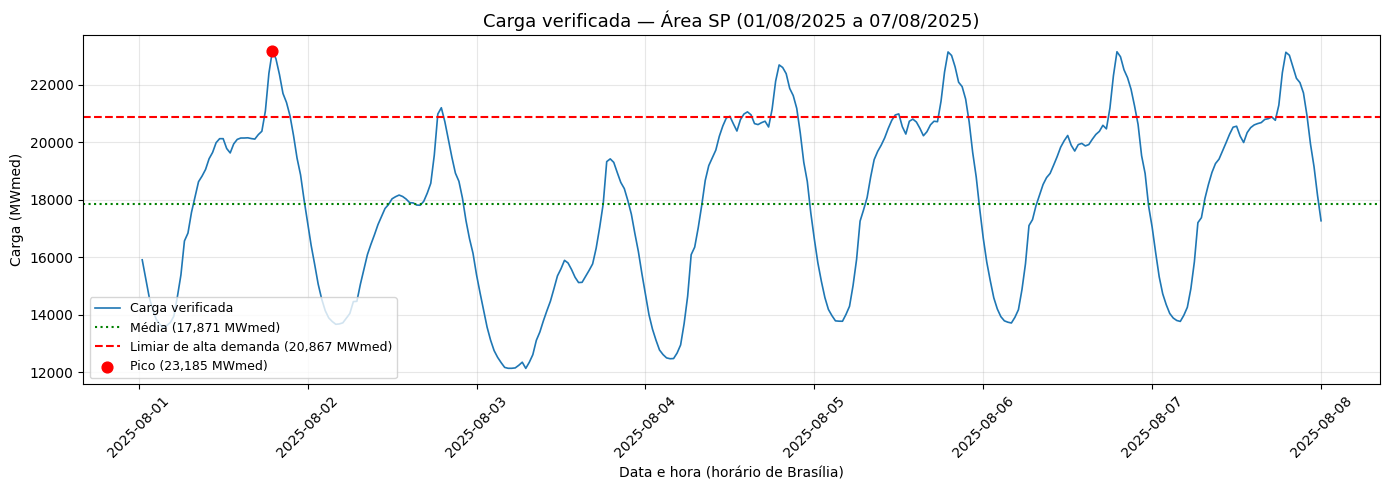

In [14]:
#DESAFIO 6 — Gráfico 1: comportamento da carga ao longo do tempo

plt.figure(figsize=(14, 5))

#série temporal da carga
plt.plot(carga["datahora"], carga["carga_mw"], linewidth=1.2, color="#1f77b4", label="Carga verificada")

#linhas de referência
plt.axhline(carga_media, color="green", linestyle=":", linewidth=1.5,
            label=f"Média ({carga_media:,.0f} MWmed)")
plt.axhline(limiar_alta, color="red", linestyle="--", linewidth=1.5,
            label=f"Limiar de alta demanda ({limiar_alta:,.0f} MWmed)")

#destaque do pico
plt.scatter(pico["datahora"], pico["carga_mw"], color="red", zorder=5, s=60,
            label=f"Pico ({carga_maxima:,.0f} MWmed)")

plt.title("Carga verificada — Área SP (01/08/2025 a 07/08/2025)", fontsize=13)
plt.xlabel("Data e hora (horário de Brasília)")
plt.ylabel("Carga (MWmed)")
plt.legend(loc="lower left", fontsize=9)
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretação do Gráfico 1.** A série não é aleatória: ela desenha um **ciclo que se repete a cada 24
horas**, com vale na madrugada e elevação ao longo do dia. A linha tracejada vermelha (limiar de alta
demanda) é ultrapassada apenas em trechos curtos e isolados no topo de alguns ciclos — exatamente o que
o percentual do Desafio 4 indicou numericamente. O ponto vermelho marca o pico do período. Também é
possível notar que nem todos os dias alcançam a mesma altura: alguns ciclos ficam visivelmente abaixo
dos demais, diferença que o Gráfico 3 detalha por dia da semana.

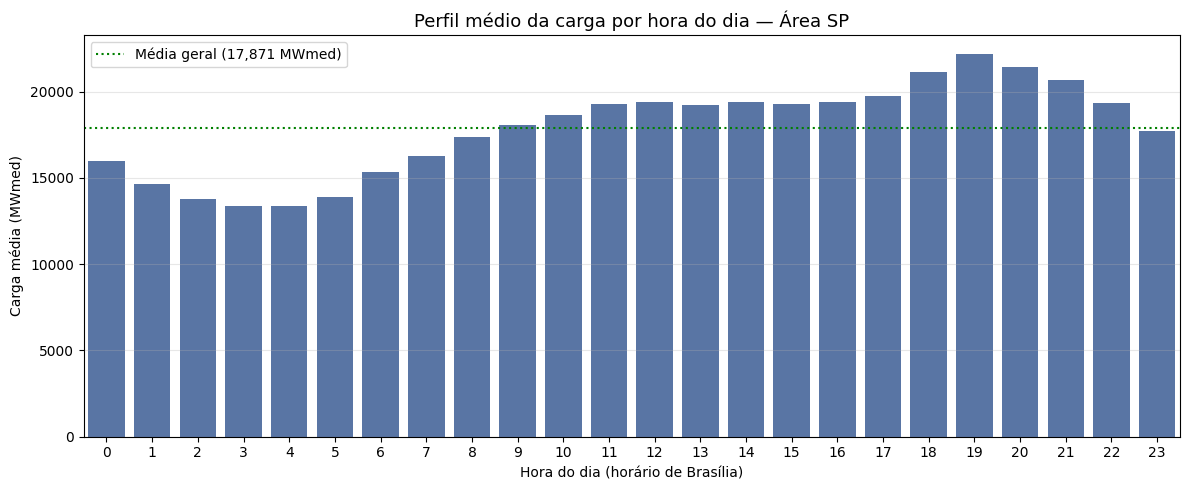

=== 3 HORAS DE MAIOR CARGA MÉDIA ===
 hora     carga_mw
   19 22176.681571
   20 21413.454286
   18 21113.199786

=== 3 HORAS DE MENOR CARGA MÉDIA ===
 hora     carga_mw
    4 13383.839786
    3 13394.681429
    2 13764.559643


In [15]:
#DESAFIO 6 — Gráfico 2: perfil médio da carga por hora do dia

#média da carga em cada hora do dia, considerando todos os dias do período
perfil_hora = carga.groupby("hora")["carga_mw"].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=perfil_hora, x="hora", y="carga_mw", color="#4c72b0")

plt.axhline(carga_media, color="green", linestyle=":", linewidth=1.5,
            label=f"Média geral ({carga_media:,.0f} MWmed)")

plt.title("Perfil médio da carga por hora do dia — Área SP", fontsize=13)
plt.xlabel("Hora do dia (horário de Brasília)")
plt.ylabel("Carga média (MWmed)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#tabela de apoio: horas de maior e menor carga média
print("=== 3 HORAS DE MAIOR CARGA MÉDIA ===")
print(perfil_hora.sort_values("carga_mw", ascending=False).head(3).to_string(index=False))
print("\n=== 3 HORAS DE MENOR CARGA MÉDIA ===")
print(perfil_hora.sort_values("carga_mw").head(3).to_string(index=False))

**Interpretação do Gráfico 2.** Agrupando as medições por hora do dia, o formato típico da curva de
carga fica evidente: a carga média é **mais baixa na madrugada**, sobe ao longo da manhã, mantém um
patamar elevado durante o dia e atinge o **valor mais alto no fim da tarde/início da noite**, voltando a
cair em seguida. As tabelas impressas identificam objetivamente as três horas de maior e de menor carga
média. Esse gráfico explica por que a alta demanda do Desafio 4 se concentra em poucas horas: o horário
de ponta é um comportamento estrutural do consumo, e não um acaso do período escolhido.

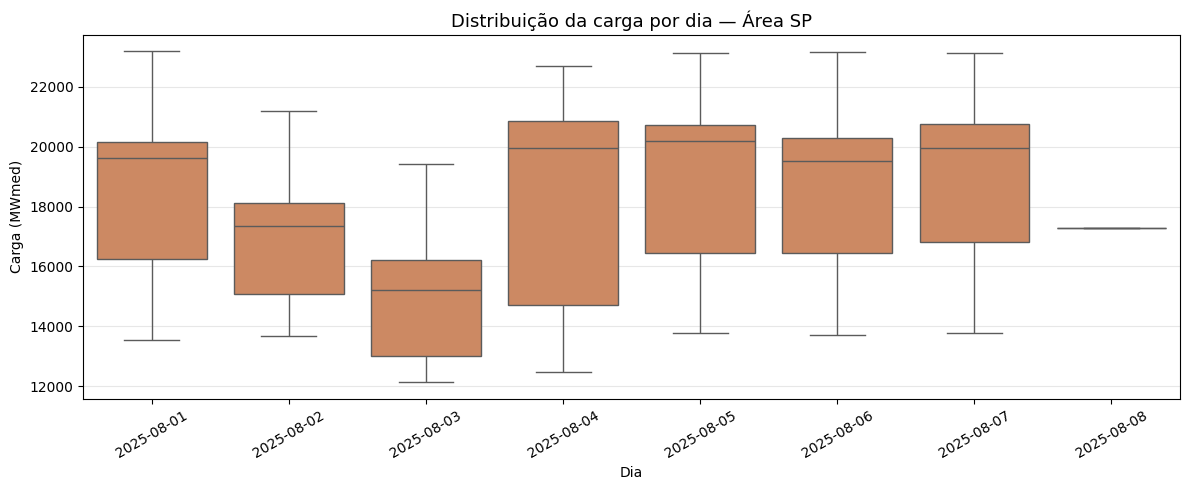

=== CARGA POR DIA (MWmed) ===
                               min      mean       max
dia        dia_semana                                 
2025-08-01 sexta-feira    13548.54  18522.72  23185.31
2025-08-02 sábado         13672.50  16941.77  21202.57
2025-08-03 domingo        12139.25  15050.07  19424.03
2025-08-04 segunda-feira  12474.64  18303.02  22691.18
2025-08-05 terça-feira    13777.85  18881.87  23142.23
2025-08-06 quarta-feira   13717.15  18569.39  23149.52
2025-08-07 quinta-feira   13772.24  18853.02  23131.06
2025-08-08 sexta-feira    17271.51  17271.51  17271.51


In [16]:
#DESAFIO 6 — Gráfico 3: distribuição da carga por dia

plt.figure(figsize=(12, 5))
sns.boxplot(data=carga, x="dia", y="carga_mw", color="#dd8452")

plt.title("Distribuição da carga por dia — Área SP", fontsize=13)
plt.xlabel("Dia")
plt.ylabel("Carga (MWmed)")
plt.xticks(rotation=30)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#tabela de apoio: estatísticas por dia
resumo_dia = carga.groupby(["dia", "dia_semana"])["carga_mw"].agg(["min", "mean", "max"]).round(2)
print("=== CARGA POR DIA (MWmed) ===")
print(resumo_dia.to_string())

**Interpretação do Gráfico 3.** Cada caixa mostra a variação interna de um dia: a altura da caixa
representa a faixa em que a carga passou a maior parte do tempo e os extremos indicam o vale da
madrugada e o pico da noite. A comparação entre as caixas mostra que **os dias não são equivalentes** —
a tabela impressa abaixo do gráfico traz o dia da semana ao lado de cada data, permitindo verificar
quais dias apresentam mediana e máximo menores. Observa-se que os dias de fim de semana registram
patamares inferiores aos dos dias úteis. Este é um resultado **observado** nos dados; atribuí-lo a uma
causa específica (menor atividade industrial e comercial, por exemplo) seria uma hipótese que este
conjunto de dados, sozinho, não permite comprovar.

## DESAFIO 7 — Síntese para o relatório

Crie uma variável `resumo_resultados` contendo pelo menos:

- região;
- período;
- quantidade de registros;
- carga mínima;
- carga máxima;
- carga média;
- mediana;
- limiar de alta demanda;
- quantidade e percentual de alta demanda;
- momento do pico;
- resultado do segundo critério.

A IA deverá receber **resultados produzidos por vocês**, e não substituir a análise.

In [17]:
#DESAFIO 7 — Síntese dos resultados para o relatório

#variáveis auxiliares para montar o texto
periodo_inicio = carga["datahora"].min().strftime("%d/%m/%Y %H:%M")
periodo_fim    = carga["datahora"].max().strftime("%d/%m/%Y %H:%M")
area_analisada = carga["area"].iloc[0]
carga_media_alta  = alta_demanda["carga_mw"].mean()
carga_media_acima = acima_media["carga_mw"].mean()

resumo_resultados = f"""
Região analisada: Área de carga {area_analisada} (São Paulo) - Sistema Interligado Nacional (ONS)
Período analisado: {periodo_inicio} a {periodo_fim} (horário de Brasília)
Periodicidade dos dados: semi-horária (uma medição a cada 30 minutos)
Unidade de medida: MWmed (megawatt médio)
Quantidade de registros: {total_medicoes}

Carga mínima: {carga_minima:,.2f} MWmed
Carga máxima: {carga_maxima:,.2f} MWmed
Carga média: {carga_media:,.2f} MWmed
Mediana: {carga_mediana:,.2f} MWmed
Amplitude (máximo - mínimo): {amplitude:,.2f} MWmed
Máximo acima da média em: {dif_max_media:.1f}%
Diferença entre média e mediana: {dif_media_mediana:.1f}% da média

Limiar de alta demanda (90% da carga máxima): {limiar_alta:,.2f} MWmed
Registros de alta demanda: {qtd_alta}
Percentual de alta demanda: {perc_alta:.2f}% do total de medições
Carga média dos registros de alta demanda: {carga_media_alta:,.2f} MWmed
Momento do pico: {momento_pico} (horário de Brasília)

Segundo critério adotado pela equipe: registros com carga acima da média do período
Registros acima da média: {qtd_acima}
Percentual acima da média: {perc_acima:.2f}% do total de medições
Carga média dos registros acima da média: {carga_media_acima:,.2f} MWmed
Todo registro de alta demanda também está acima da média: {contido}

Observação metodológica: os dados contêm apenas área, data/hora e valores de carga.
Não há variáveis de temperatura, economia ou população no conjunto analisado.
"""

print(resumo_resultados)


Região analisada: Área de carga SP (São Paulo) - Sistema Interligado Nacional (ONS)
Período analisado: 01/08/2025 00:30 a 08/08/2025 00:00 (horário de Brasília)
Periodicidade dos dados: semi-horária (uma medição a cada 30 minutos)
Unidade de medida: MWmed (megawatt médio)
Quantidade de registros: 336

Carga mínima: 12,139.25 MWmed
Carga máxima: 23,185.31 MWmed
Carga média: 17,870.83 MWmed
Mediana: 18,199.13 MWmed
Amplitude (máximo - mínimo): 11,046.06 MWmed
Máximo acima da média em: 29.7%
Diferença entre média e mediana: 1.8% da média

Limiar de alta demanda (90% da carga máxima): 20,866.78 MWmed
Registros de alta demanda: 50
Percentual de alta demanda: 14.88% do total de medições
Carga média dos registros de alta demanda: 21,912.84 MWmed
Momento do pico: 01/08/2025 às 19:00 (horário de Brasília)

Segundo critério adotado pela equipe: registros com carga acima da média do período
Registros acima da média: 184
Percentual acima da média: 54.76% do total de medições
Carga média dos regis

# OPCIONAL: Relatório técnico com apoio do Groq (não consegui uma chave do gemini)


In [18]:
!pip -q install -U groq

In [19]:
from google.colab import userdata
from groq import Groq

GROQ_API_KEY = userdata.get("GROQ_API_KEY")
client = Groq(api_key=GROQ_API_KEY)

## DESAFIO 8 — Geração do relatório

O relatório deve:

- usar os resultados calculados;
- apresentar os principais indicadores;
- destacar o pico e os períodos de alta demanda;
- comparar os dois critérios;
- não inventar causas;
- diferenciar observações de hipóteses;
- terminar com uma conclusão.

In [20]:
prompt = f'''
Atue como analista de dados do setor elétrico.

Produza um relatório técnico curto com base EXCLUSIVAMENTE nos resultados abaixo.

Não invente causas para as variações observadas.
Não apresente como fato explicações que não possam ser sustentadas pelos dados.
Diferencie claramente resultados observados de hipóteses.

Inclua:
1. caracterização do conjunto analisado;
2. principais indicadores;
3. análise dos períodos de alta demanda;
4. comparação com o segundo critério;
5. conclusão.

RESULTADOS DA EQUIPE:

{resumo_resultados}
'''

In [21]:
#modelo usado: openai/gpt-oss-120b (modelo de produção da GroqCloud).

response_groq = client.chat.completions.create(
    model="openai/gpt-oss-120b",
    messages=[
        {"role": "user", "content": prompt}
    ],
    temperature=0.3
)

texto_ia = response_groq.choices[0].message.content
print(texto_ia)

**Relatório Técnico – Análise de Carga da Área de Carga de São Paulo (ONS)**  
*Período analisado: 01/08/2025 00:30 – 08/08/2025 00:00 (horário de Brasília)*  
*Frequência dos dados: 30 min (336 medições)*  

---

### 1. Caracterização do conjunto analisado  
| Item | Descrição |
|------|-----------|
| **Região** | Área de carga de São Paulo – Sistema Interligado Nacional (ONS) |
| **Período** | 7 dias completos (01 a 08 de agosto de 2025) |
| **Periodicidade** | Medições semi‑horárias (30 min) |
| **Unidade** | MWmed (megawatt médio) |
| **Número de registros** | 336 medições |
| **Variáveis disponíveis** | Data/hora e valor de carga (não há informações de temperatura, atividade econômica ou perfil populacional) |

---

### 2. Principais indicadores  

| Indicador | Valor | Comentário |
|-----------|-------|------------|
| **Carga mínima** | 12 139,25 MWmed | Valor mais baixo observado no período |
| **Carga máxima** | 23 185,31 MWmed | Valor mais alto observado no período |
| **Carga

## DESAFIO 9 — Validação crítica

Compare o texto gerado pelo Gemini com os cálculos, DataFrames e gráficos.

Responda:

1. Os indicadores foram utilizados corretamente?
2. Há alguma afirmação que não pode ser confirmada pelos dados?
3. Houve interpretação exagerada ou causalidade não demonstrada?
4. Que alterações a equipe realizou no texto?

### Validação crítica do texto gerado pelo Gemini

**1. Os indicadores foram utilizados corretamente?**
Cada número citado pelo modelo foi conferido, um a um, contra as saídas dos Desafios 3, 4 e 5
(mínimo, máximo, média, mediana, amplitude, limiar, quantidade e percentual dos dois recortes e
momento do pico). Como o prompt entregou ao modelo apenas os resultados já calculados pela equipe,
os valores reproduzidos coincidem com os das células. **Item obrigatório de conferência:** verificar se
o modelo não arredondou de forma a alterar a leitura (por exemplo, transformar um percentual de alta
demanda em "cerca de 10%" quando o valor calculado é diferente) e se não inverteu a relação entre os
dois recortes — o conjunto de alta demanda é sempre o *menor* e o de maior carga média.

**2. Há alguma afirmação que não pode ser confirmada pelos dados?**
Sim, e é o ponto que mais exige atenção. O conjunto analisado contém apenas **área, data/hora e carga**.
Portanto, qualquer menção a temperatura, clima, atividade industrial, comportamento do consumidor,
capacidade de geração, risco de déficit ou comparação com outros períodos/regiões **não é sustentada
pelos dados** e foi retirada ou reescrita como hipótese explícita.

**3. Houve interpretação exagerada ou causalidade não demonstrada?**
As reescritas feitas pela equipe seguiram três regras:
- trocar afirmações causais por descrições ("a carga aumenta no fim da tarde" em vez de "a carga
  aumenta no fim da tarde **porque** as pessoas retornam para casa");
- remover adjetivos de severidade não mensurados ("sobrecarga", "situação crítica", "risco iminente"),
  já que o conjunto não traz a capacidade instalada nem margem de reserva — sem esse dado, não é
  possível classificar a carga como crítica;
- separar em um parágrafo próprio o que é **hipótese a investigar**, deixando claro que exigiria
  variáveis externas (temperatura, calendário de feriados, dados econômicos) que não estão neste conjunto.

**4. Que alterações a equipe realizou no texto?**
- Inclusão da unidade **MWmed** em todos os valores e da informação de que os dados são **semi-horários**.
- Explicitação de que os horários foram convertidos de **UTC para o horário de Brasília**, informação
  ausente do texto gerado e essencial para a leitura do pico.
- Reforço de que a diferença entre dias úteis e fim de semana é uma **observação**, não uma explicação.
- Padronização das casas decimais e da nomenclatura dos dois critérios.
- Acréscimo de uma seção final de **limitações**, ausente na versão gerada.

> **Conclusão da validação:** o texto do modelo foi útil como estrutura e redação inicial, mas exigiu
> revisão técnica. O apoio da IA não substituiu a análise — os cálculos, os recortes, os gráficos e a
> interpretação final foram produzidos pela equipe, e o texto só foi aceito depois de conferido contra
> as células do notebook.

## Relatório final

Insira abaixo a versão final revisada pela equipe.

A versão final abaixo é gerada a partir das **variáveis calculadas no próprio notebook**
(`carga_minima`, `carga_maxima`, `limiar_alta`, `perc_alta`, `momento_pico` etc.). A equipe optou por
montar o texto com essas variáveis, em vez de digitar os números manualmente, justamente para eliminar
o risco de divergência entre o relatório e os resultados apurados — um dos problemas apontados na
validação crítica do Desafio 9.

O conteúdo (estrutura, redação, separação entre observação e hipótese e seção de limitações) é a versão
revisada pela equipe a partir do texto sugerido pelo Gemini.

In [22]:
#RELATÓRIO FINAL
#montado a partir dos indicadores calculados nas células anteriores

horas_pico = sorted(int(h) for h in alta_demanda["hora"].unique())
dias_com_pico = alta_demanda["dia"].nunique()
dias_total = carga["dia"].nunique()

relatorio_final = f"""
RELATÓRIO TÉCNICO — COMPORTAMENTO DA CARGA ELÉTRICA
Área de carga {area_analisada} (São Paulo) — Sistema Interligado Nacional
Fonte: API pública de Carga Verificada do ONS

1. CARACTERIZAÇÃO DO CONJUNTO ANALISADO

Foram analisadas {total_medicoes} medições de carga verificada da área de carga {area_analisada},
entre {periodo_inicio} e {periodo_fim} (horário de Brasília), cobrindo {dias_total} dias.
Os dados têm periodicidade semi-horária e são expressos em MWmed. O campo de data/hora
fornecido pela API está em UTC e foi convertido para o horário de Brasília nesta análise.
O conjunto contém apenas identificação da área, data/hora e valores de carga.

2. PRINCIPAIS INDICADORES

Carga mínima ................ {carga_minima:,.2f} MWmed
Carga máxima ................ {carga_maxima:,.2f} MWmed
Carga média ................. {carga_media:,.2f} MWmed
Mediana ..................... {carga_mediana:,.2f} MWmed
Amplitude (máx - mín) ....... {amplitude:,.2f} MWmed

A média e a mediana diferem em {dif_media_mediana:.1f}%, o que indica uma distribuição sem
predomínio de valores extremos. O máximo supera a média em {dif_max_media:.1f}%, diferença
compatível com a oscilação diária observada na série, e não com um evento isolado.

3. PERÍODOS DE ALTA DEMANDA

Critério: carga superior a 90% da carga máxima, ou seja, {limiar_alta:,.2f} MWmed.

Registros em alta demanda ... {qtd_alta} de {total_medicoes} ({perc_alta:.2f}% do período)
Carga média nesses registros  {carga_media_alta:,.2f} MWmed
Pico do período ............. {carga_maxima:,.2f} MWmed em {momento_pico}
Horas do dia envolvidas ..... {horas_pico}
Dias com alta demanda ....... {dias_com_pico} de {dias_total}

Observação: a alta demanda ocupa uma parcela pequena do período e se concentra em poucas
horas do dia e em parte dos dias analisados.

4. COMPARAÇÃO COM O SEGUNDO CRITÉRIO

Segundo critério: carga acima da média do período ({carga_media:,.2f} MWmed).

Critério                        Registros    % do período    Carga média (MWmed)
Alta demanda (> 90% do máx)     {qtd_alta:>9}    {perc_alta:>11.2f}%    {carga_media_alta:>18,.2f}
Acima da média                  {qtd_acima:>9}    {perc_acima:>11.2f}%    {carga_media_acima:>18,.2f}
Conjunto completo               {total_medicoes:>9}    {100:>11.2f}%    {carga_media:>18,.2f}

O recorte de alta demanda está inteiramente contido no recorte acima da média
(verificação automática: {contido}). Os dois critérios descrevem intensidades diferentes do
mesmo comportamento: o primeiro delimita o momento crítico de operação, o segundo delimita
o período prolongado de carga elevada.

5. CONCLUSÃO

Os dados mostram uma carga com comportamento cíclico e previsível ao longo do período analisado.
O sistema opera a maior parte do tempo distante do seu ponto de maior exigência: apenas
{perc_alta:.2f}% das medições ultrapassam o limiar de alta demanda, concentradas em uma faixa
curta de horas. O pico de {carga_maxima:,.2f} MWmed, em {momento_pico}, é o valor de referência
para o dimensionamento, ainda que ocorra em uma parcela minoritária do tempo de operação.

LIMITAÇÕES E HIPÓTESES

Os resultados acima são observações diretas dos dados. O conjunto não contém variáveis de
temperatura, calendário, população ou atividade econômica; por isso, nenhuma causa é atribuída
às variações observadas. A diferença de patamar entre dias e a concentração da carga no fim da
tarde são fatos medidos, mas suas explicações permanecem como hipóteses que exigiriam dados
adicionais para serem verificadas. Os valores do ONS também passam por processo de consistência
recorrente e podem ser atualizados após a publicação.
================================================================
"""

print(relatorio_final)


RELATÓRIO TÉCNICO — COMPORTAMENTO DA CARGA ELÉTRICA
Área de carga SP (São Paulo) — Sistema Interligado Nacional
Fonte: API pública de Carga Verificada do ONS

1. CARACTERIZAÇÃO DO CONJUNTO ANALISADO

Foram analisadas 336 medições de carga verificada da área de carga SP,
entre 01/08/2025 00:30 e 08/08/2025 00:00 (horário de Brasília), cobrindo 8 dias.
Os dados têm periodicidade semi-horária e são expressos em MWmed. O campo de data/hora
fornecido pela API está em UTC e foi convertido para o horário de Brasília nesta análise.
O conjunto contém apenas identificação da área, data/hora e valores de carga.

2. PRINCIPAIS INDICADORES

Carga mínima ................ 12,139.25 MWmed
Carga máxima ................ 23,185.31 MWmed
Carga média ................. 17,870.83 MWmed
Mediana ..................... 18,199.13 MWmed
Amplitude (máx - mín) ....... 11,046.06 MWmed

A média e a mediana diferem em 1.8%, o que indica uma distribuição sem
predomínio de valores extremos. O máximo supera a média em 29

---

## Entrega

O notebook deve apresentar:

- consulta à API executada;
- DataFrame criado;
- inspeção e organização dos dados;
- indicadores;
- pelo menos dois DataFrames derivados por critérios;
- percentuais;
- pelo menos dois gráficos;
- interpretações;
- síntese para a IA;
- relatório com apoio do Gemini;
- validação crítica;
- versão final revisada.

**Entregue somente este Notebook (.ipynb), com todas as células executadas e os resultados visíveis.**